In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
daily_sales = pd.read_csv("data/salesdaily.csv")
weekly_sales = pd.read_csv("data/salesweekly.csv")
monthly_sales = pd.read_csv("data/salesmonthly.csv")

# Dataset information
print("Daily Sales Shape:", daily_sales.shape)
print("Weekly Sales Shape:", weekly_sales.shape)
print("Monthly Sales Shape:", monthly_sales.shape)

# First 5 rows
daily_sales.head()

Daily Sales Shape: (2106, 13)
Weekly Sales Shape: (302, 9)
Monthly Sales Shape: (70, 9)


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [5]:
# Dataset Information
print(daily_sales.info())

# Missing values
print("\nMissing Values:")
print(daily_sales.isnull().sum())

# Statistical summary
daily_sales.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 247.1 KB
None

Missing Values:
datum           0
M01AB           0
M01AE           0
N02BA           0
N02BE           0
N05B            0
N05C            0
R03             0
R06             0
Year           

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
std,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000


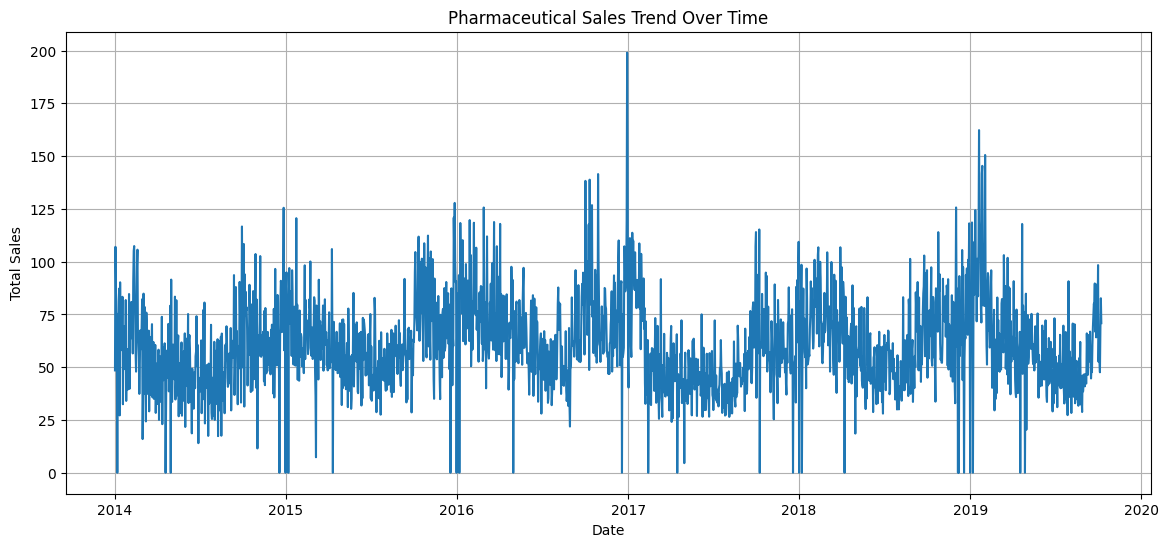

In [6]:
# Convert date column to datetime
daily_sales['datum'] = pd.to_datetime(daily_sales['datum'])

# Set style
plt.figure(figsize=(14,6))

# Total sales trend
daily_sales['Total_Sales'] = (
    daily_sales['M01AB'] +
    daily_sales['M01AE'] +
    daily_sales['N02BA'] +
    daily_sales['N02BE'] +
    daily_sales['N05B'] +
    daily_sales['N05C'] +
    daily_sales['R03'] +
    daily_sales['R06']
)

plt.plot(daily_sales['datum'], daily_sales['Total_Sales'])
plt.title("Pharmaceutical Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

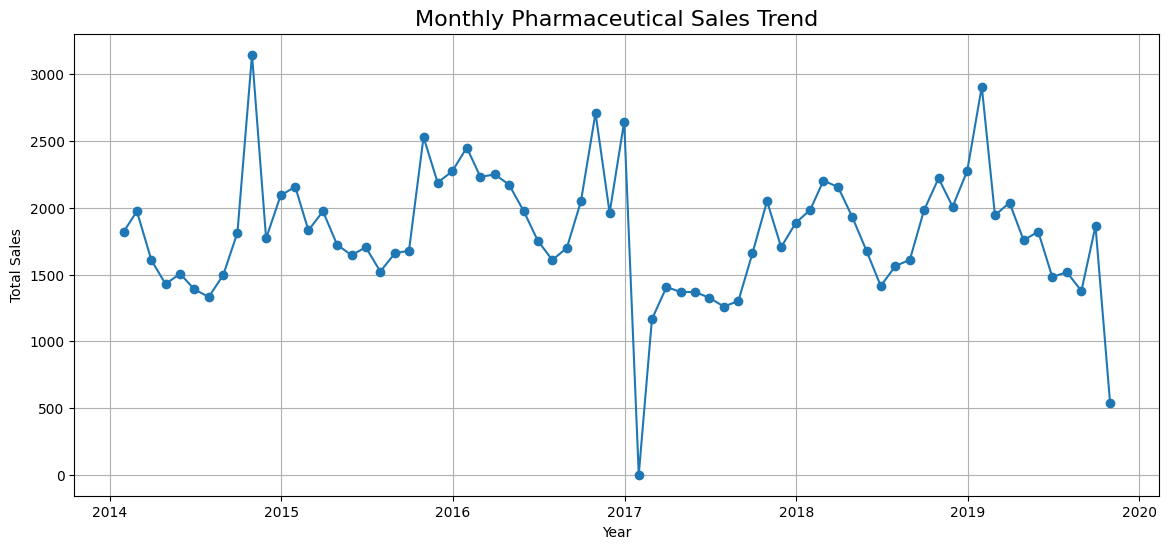

In [7]:
# Monthly Sales Trend

monthly_sales['datum'] = pd.to_datetime(monthly_sales['datum'])

# Create total sales column
monthly_sales['Total_Sales'] = (
    monthly_sales['M01AB'] +
    monthly_sales['M01AE'] +
    monthly_sales['N02BA'] +
    monthly_sales['N02BE'] +
    monthly_sales['N05B'] +
    monthly_sales['N05C'] +
    monthly_sales['R03'] +
    monthly_sales['R06']
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales['datum'],
    monthly_sales['Total_Sales'],
    marker='o'
)

plt.title("Monthly Pharmaceutical Sales Trend", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

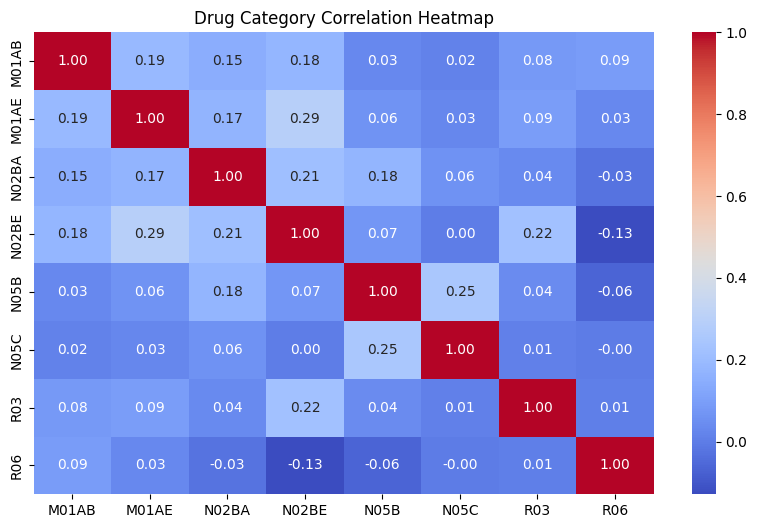

In [8]:
# Drug category correlation heatmap

drug_columns = [
    'M01AB', 'M01AE', 'N02BA',
    'N02BE', 'N05B', 'N05C',
    'R03', 'R06'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    daily_sales[drug_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Drug Category Correlation Heatmap")
plt.show()

In [11]:
from prophet import Prophet

# Prepare data for Prophet
forecast_data = monthly_sales[['datum', 'Total_Sales']].copy()

# Prophet requires column names ds and y
forecast_data.rename(
    columns={
        'datum': 'ds',
        'Total_Sales': 'y'
    },
    inplace=True
)

# Create model
model = Prophet()

# Train model
model.fit(forecast_data)

# Create future dates (12 months prediction)
future = model.make_future_dataframe(periods=12, freq='ME')

# Predict
forecast = model.predict(future)

# Show prediction
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

12:30:01 - cmdstanpy - INFO - Chain [1] start processing
12:30:01 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
77,2020-06-30,1339.609385,912.952491,1776.632422
78,2020-07-31,1192.208469,760.724944,1646.332150
79,2020-08-31,1279.616899,840.066270,1728.529280
80,2020-09-30,1707.656812,1243.739685,2178.825580
81,2020-10-31,2665.513093,2188.264017,3121.034312


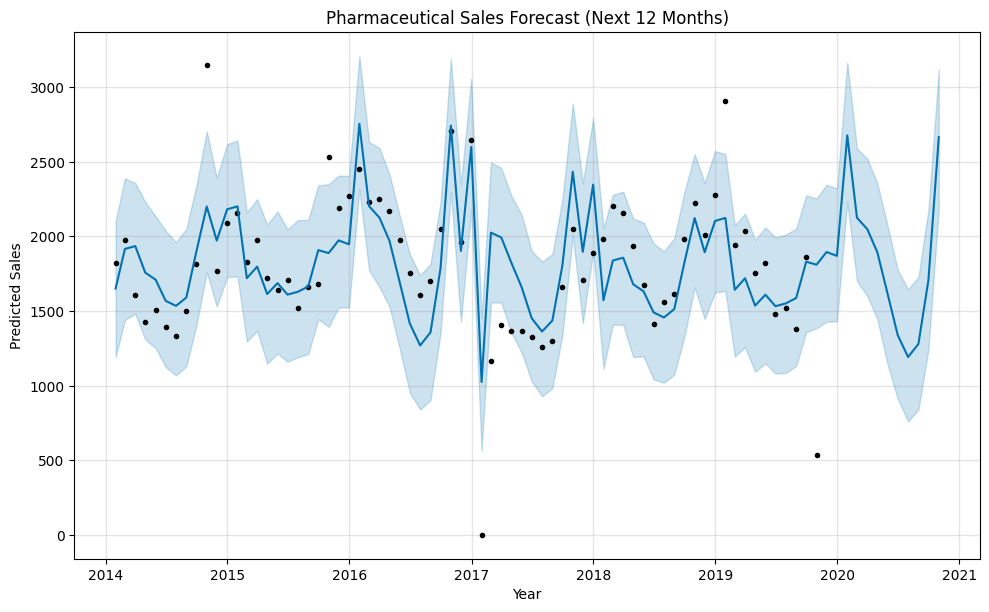

In [12]:
# Forecast plot

fig = model.plot(forecast)

plt.title("Pharmaceutical Sales Forecast (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Predicted Sales")

plt.show()

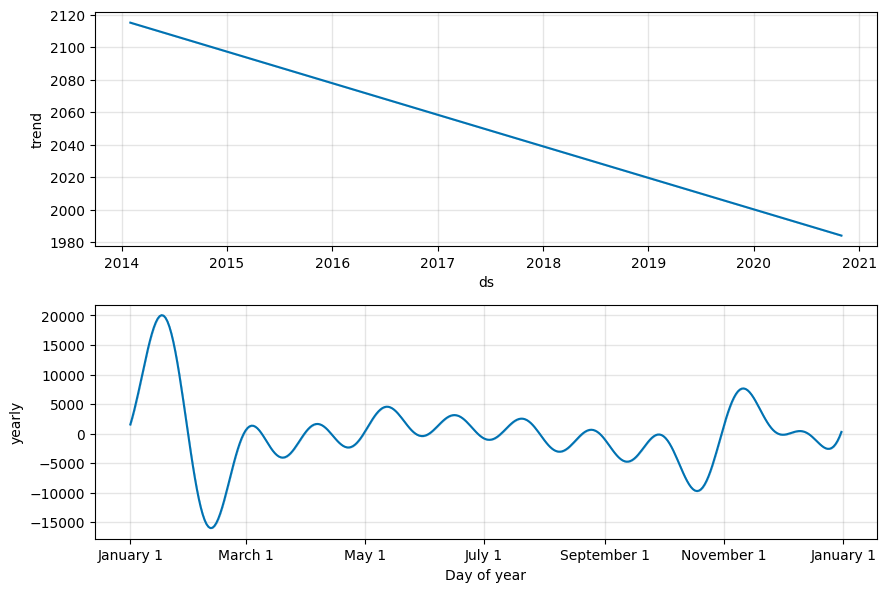

In [13]:
# Prophet Components Plot
fig2 = model.plot_components(forecast)

plt.show()

In [14]:
# Save forecast results

forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecast_output.to_csv(
    "outputs/pharma_sales_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!
